In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv
/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_30_sec.csv
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00005.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00057.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00020.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00072.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00040.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00043.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00010.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00071.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/image

In [17]:
import os

DATASET_PATH = "/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original"

genres = os.listdir(DATASET_PATH)
print("Genres:", genres)


Genres: ['disco', 'metal', 'reggae', 'blues', 'rock', 'classical', 'jazz', 'hiphop', 'country', 'pop']


In [18]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE


In [19]:
test_genre = genres[0]
test_file = os.listdir(os.path.join(DATASET_PATH, test_genre))[0]
test_path = os.path.join(DATASET_PATH, test_genre, test_file)

print("Testing file:", test_path)

y, sr = librosa.load(test_path, duration=30)
print("Audio loaded, length:", len(y))


Testing file: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/disco/disco.00031.wav
Audio loaded, length: 661500


In [20]:
import os
import librosa
import numpy as np

def extract_mfcc(file_path, n_mfcc=13, max_len=130):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_len:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)))
        else:
            mfcc = mfcc[:, :max_len]
        return mfcc
    except:
        return None


In [21]:
X_audio = []
y_genre = []

genres = os.listdir(DATASET_PATH)

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    for file in os.listdir(genre_path):
        mfcc = extract_mfcc(os.path.join(genre_path, file))
        if mfcc is not None:
            X_audio.append(mfcc)
            y_genre.append(genre)

X_audio = np.array(X_audio)
print(X_audio.shape)


/tmp/ipykernel_55/2629312480.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


(999, 13, 130)


In [22]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_audio_t = torch.FloatTensor(X_audio).unsqueeze(1).to(device)
print(X_audio_t.shape)


torch.Size([999, 1, 13, 130])


In [23]:
class AudioVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(16*7*65, latent_dim)
        self.fc_logvar = nn.Linear(16*7*65, latent_dim)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        return mu, logvar


In [24]:
audio_vae = AudioVAE(latent_dim=16).to(device)

with torch.no_grad():
    mu_audio, _ = audio_vae(X_audio_t)

Z_audio = mu_audio.cpu().numpy()
print("Audio latent shape:", Z_audio.shape)


Audio latent shape: (999, 16)


In [25]:
import os

print(os.listdir("/kaggle/input"))


['gtzan-dataset-music-genre-classification', 'song-lyrics']


In [26]:
import os

os.listdir("/kaggle/input/song-lyrics")


['lid.176.bin',
 '__results__.html',
 'df_eng.zip',
 'song_distributions.png',
 'vectors.npy',
 '__resultx__.html',
 '__notebook__.ipynb',
 '__results___files',
 'song_popularity_by_language.png',
 '__output__.json',
 'ds2_processed.zip',
 'custom.css']

In [27]:
import zipfile
import os

zip_path = "/kaggle/input/song-lyrics/df_eng.zip"
extract_path = "/kaggle/working/lyrics_eng"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['df_eng.csv']

In [28]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/working/lyrics_eng/df_eng.csv",
    nrows=3000   # VERY IMPORTANT
)

print(df.shape)
df.head()


(3000, 7)


,Unnamed: 0,title,tag,artist,year,views,lyrics
0,0,Killa Cam,rap,Cam'ron,2004,173166,"Killa Cam, Killa Cam, Cam Killa Cam, Killa Ca..."
1,1,Can I Live,rap,JAY-Z,1996,468624,"Yeah, hah, yeah, Roc-A-Fella We invite you ..."
2,2,Forgive Me Father,rap,Fabolous,2003,4743,Maybe cause I'm eatin And these bastards fiend...
3,3,Down and Out,rap,Cam'ron,2004,144404,"Ugh, Killa! Baby! Kanye, this that 1970s He..."
4,4,Fly In,rap,Lil Wayne,2005,78271,"So they ask me ""Young boy What you gon' do th..."


In [29]:
import re

def clean_lyrics(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_lyrics"] = df["lyrics"].apply(clean_lyrics)


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    min_df=5
)

X_lyrics = tfidf.fit_transform(df["clean_lyrics"])

print("Lyrics TF-IDF shape:", X_lyrics.shape)


Lyrics TF-IDF shape: (3000, 1000)


In [31]:
#Convert TF-IDF to Torch Tensor
import torch

X_lyrics_t = torch.FloatTensor(X_lyrics.toarray())
print(X_lyrics_t.shape)


torch.Size([3000, 1000])


In [32]:
#define lyrics autoencoder
import torch.nn as nn

class LyricsAE(nn.Module):
    def __init__(self, input_dim=1000, latent_dim=32):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


In [33]:
#train lyrics encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LyricsAE(input_dim=1000, latent_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

X_lyrics_t = X_lyrics_t.to(device)

epochs = 30

for epoch in range(epochs):
    optimizer.zero_grad()
    recon, z = model(X_lyrics_t)
    loss = criterion(recon, X_lyrics_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/30], Loss: 0.2011
Epoch [20/30], Loss: 0.0486
Epoch [30/30], Loss: 0.0013


In [34]:
#extract latent vectors
with torch.no_grad():
    _, Z_lyrics = model(X_lyrics_t)

Z_lyrics = Z_lyrics.cpu().numpy()
print("Lyrics latent shape:", Z_lyrics.shape)


Lyrics latent shape: (3000, 32)


In [35]:
import numpy as np

np.random.seed(42)

idx = np.random.choice(len(Z_lyrics), size=len(Z_audio), replace=False)
Z_lyrics_aligned = Z_lyrics[idx]

print(Z_lyrics_aligned.shape)


(999, 32)


In [36]:
#fuse modalities
Z_fused = np.concatenate([Z_audio, Z_lyrics_aligned], axis=1)
print("Fused shape:", Z_fused.shape)


Fused shape: (999, 48)


In [37]:
class BetaVAE(nn.Module):
    def __init__(self, input_dim=48, latent_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.fc_dec1 = nn.Linear(latent_dim, 64)
        self.fc_dec2 = nn.Linear(64, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc_dec1(z))
        return self.fc_dec2(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [38]:
def beta_vae_loss(recon, x, mu, logvar, beta=4):
    recon_loss = nn.MSELoss()(recon, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl


In [39]:
X_fused_t = torch.FloatTensor(Z_fused).to(device)

model = BetaVAE(input_dim=48, latent_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 40
for epoch in range(epochs):
    optimizer.zero_grad()
    recon, mu, logvar = model(X_fused_t)
    loss = beta_vae_loss(recon, X_fused_t, mu, logvar, beta=4)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/40], Loss: 104.1562
Epoch [20/40], Loss: 94.4910
Epoch [30/40], Loss: 89.9858
Epoch [40/40], Loss: 84.0430


In [40]:
with torch.no_grad():
    _, mu, _ = model(X_fused_t)

Z_joint = mu.cpu().numpy()
print("Joint latent shape:", Z_joint.shape)


Joint latent shape: (999, 16)


In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from collections import Counter
import numpy as np

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(Z_joint)


In [46]:
genres = []
for folder in os.listdir("/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original"):
    for f in os.listdir(f"/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/{folder}"):
        genres.append(folder)

genres = genres[:len(Z_joint)]  # align


In [47]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(genres)


In [48]:
sil_score = silhouette_score(Z_joint, clusters)


In [50]:
ari = adjusted_rand_score(labels, clusters)


In [51]:
nmi = normalized_mutual_info_score(labels, clusters)


In [52]:
def cluster_purity(y_true, y_pred):
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        label_counts = Counter(y_true[idx])
        total += label_counts.most_common(1)[0][1]
    return total / len(y_true)

purity = cluster_purity(labels, clusters)


In [53]:
print(f"Silhouette Score: {sil_score:.4f}")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Purity: {purity:.4f}")


Silhouette Score: 0.1529
ARI: 0.0767
NMI: 0.1753
Purity: 0.2773


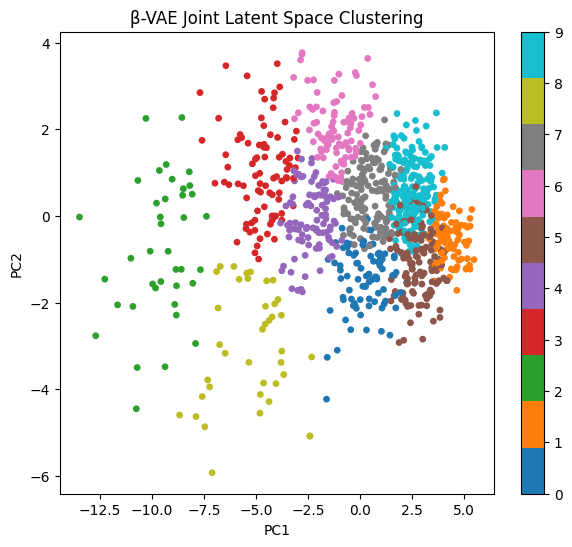

In [54]:
#Latent Space (2D PCA)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z_joint)

plt.figure(figsize=(7,6))
plt.scatter(Z_2d[:,0], Z_2d[:,1], c=clusters, cmap="tab10", s=15)
plt.title("β-VAE Joint Latent Space Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()


In [55]:
#Cluster Distribution over Genres
import pandas as pd

df_cluster = pd.DataFrame({
    "Cluster": clusters,
    "Genre": labels
})

pd.crosstab(df_cluster["Cluster"], df_cluster["Genre"])


Genre,0,1,2,3,4,5,6,7,8,9
Cluster,,,,,,,,,,
0,7,0,7,8,17,8,2,8,18,9
1,4,0,5,12,10,1,31,24,0,6
2,1,34,0,0,0,4,0,0,0,0
3,11,29,17,2,1,16,0,1,7,2
4,20,9,13,1,5,25,1,5,13,7
5,2,0,8,17,25,11,6,41,10,11
6,12,15,16,6,1,14,0,0,13,15
7,12,3,21,24,11,12,9,12,23,16
8,5,8,3,0,5,7,0,2,7,2


In [56]:
with torch.no_grad():
    recon, _, _ = model(X_fused_t)

mse = nn.MSELoss()(recon, X_fused_t).item()
print("Reconstruction MSE:", mse)


Reconstruction MSE: 74.69720458984375


In [68]:
X_audio_numeric = X_audio_numeric.iloc[:999]
clusters_raw = clusters_raw[:999]


In [69]:
sil_raw = silhouette_score(X_audio_numeric, clusters_raw)
ari_raw = adjusted_rand_score(labels, clusters_raw)
nmi_raw = normalized_mutual_info_score(labels, clusters_raw)
purity_raw = cluster_purity(labels, clusters_raw)

print(f"Raw Features → Silhouette: {sil_raw:.4f}")
print(f"Raw Features → ARI: {ari_raw:.4f}")
print(f"Raw Features → NMI: {nmi_raw:.4f}")
print(f"Raw Features → Purity: {purity_raw:.4f}")


Raw Features → Silhouette: 0.4556
Raw Features → ARI: 0.0845
Raw Features → NMI: 0.1644
Raw Features → Purity: 0.2503


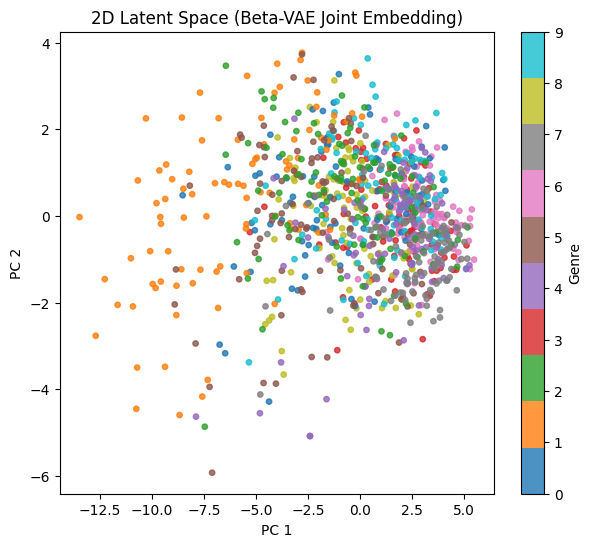

In [70]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce latent space to 2D
pca = PCA(n_components=2, random_state=42)
Z_2d = pca.fit_transform(Z_joint)

plt.figure(figsize=(7,6))
scatter = plt.scatter(
    Z_2d[:, 0], Z_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=15,
    alpha=0.8
)
plt.colorbar(scatter, label="Genre")
plt.title("2D Latent Space (Beta-VAE Joint Embedding)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


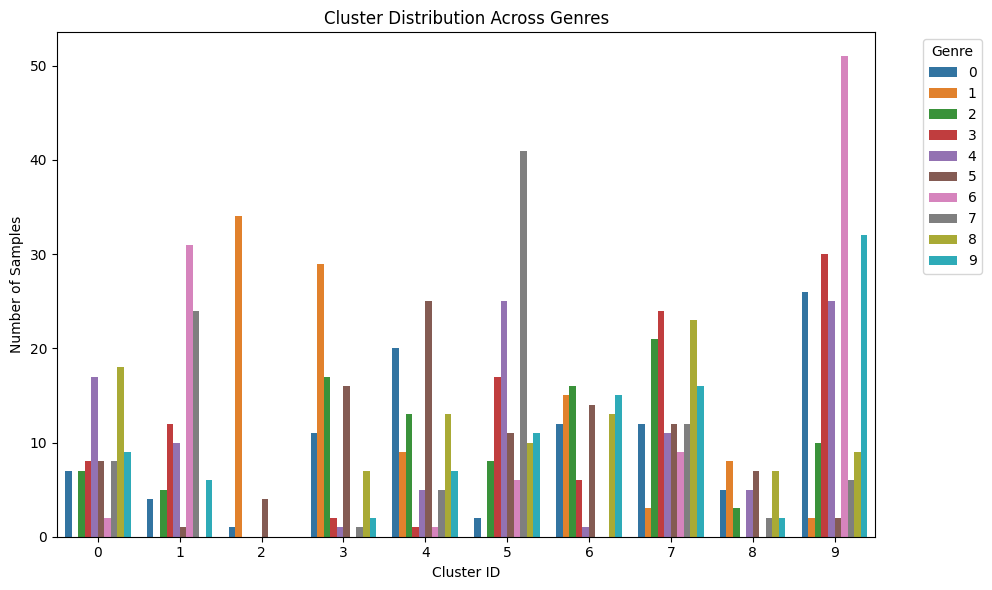

In [71]:
import pandas as pd
import seaborn as sns

df_vis = pd.DataFrame({
    "Cluster": clusters,
    "Genre": labels
})

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_vis,
    x="Cluster",
    hue="Genre",
    palette="tab10"
)
plt.title("Cluster Distribution Across Genres")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Samples")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
